In [ ]:
             E-COMMERCE-SALES INTRODUCTION.

   
This project focuses on analyzing e-commerce sales data to understand the company sales performance, 
customer purchasing behavior, product performance and overall business trends using Python, Pandas, 
NumPy, Matplotlib, and Seaborn, the project will involve data cleaning, exploratory data analysis (EDA),
and visualization to uncover meaningful patterns and insights.

The analysis will examine key areas such as sales revenue, profit, order volume, product categories, 
customer segments, and sales trends over time. The insights obtained from the analysis can help the 
business identify high-performing products, understand customer preferences, improve sales strategies, 
and make more informed, data-driven decisions.


In [1]:
# Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import dataset

df = pd.read_csv("E-Commerce-Sales.csv")

In [3]:
# Study the dataset
# Identify first 10 rows
df.head(10)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,$373.65,0.28,Wallet,10,4.7,"$1,883.20"
1,10002,1/2/2022,1435,Clothing,South,7,$47.74,0.09,Card,6,3.9,$304.10
2,10003,1/3/2022,1860,Beauty,East,3,$311.28,0.31,COD,6,2.5,$644.35
3,10004,1/4/2022,1270,Electronics,West,5,$524.47,0.02,Wallet,6,1.6,"$2,569.90"
4,10005,1/5/2022,1106,Clothing,West,5,$139.87,0.33,Wallet,4,4.9,$468.56
5,10006,1/6/2022,1071,Electronics,West,2,$264.44,0.20,Card,3,3.3,$423.10
6,10007,1/7/2022,1700,Clothing,South,6,$564.60,0.23,Card,1,1.8,"$2,608.45"
7,10008,1/8/2022,1020,Beauty,North,6,$265.71,0.13,Card,2,3.7,"$1,387.01"
8,10009,1/9/2022,1614,Clothing,South,6,$224.65,0.27,Card,2,1.4,$983.97
9,10010,1/10/2022,1121,Clothing,West,4,$272.71,0.06,Card,10,4.5,"$1,025.39"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   object 
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 468.9+ KB


In [7]:
df.shape

(5000, 12)

In [8]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [9]:
df.dtypes

order_id              int64
order_date           object
customer_id           int64
product_category     object
region               object
quantity              int64
unit_price           object
discount            float64
payment_method       object
delivery_days         int64
customer_rating     float64
revenue              object
dtype: object

In [10]:
# Do the necessary conversions

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')

df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

In [11]:
df.dtypes

order_id                     int64
order_date          datetime64[ns]
customer_id                  int64
product_category            object
region                      object
quantity                     int64
unit_price                 float64
discount                   float64
payment_method              object
delivery_days                int64
customer_rating            float64
revenue                    float64
dtype: object

In [5]:
# Check for missing and duplicate values

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

Duplicate rows:
0


In [13]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()

In [14]:
df['discount_amount'] = df['revenue'] * df['discount']
df['net_revenue'] = df['revenue'] - df['discount_amount']

In [15]:
df.head(10)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,year,month,month_name,discount_amount,net_revenue
0,10001,2022-01-01,1102,Beauty,South,7,NaN,0.28,Wallet,10,4.7,NaN,2022,1,January,NaN,NaN
1,10002,2022-01-02,1435,Clothing,South,7,NaN,0.09,Card,6,3.9,NaN,2022,1,January,NaN,NaN
2,10003,2022-01-03,1860,Beauty,East,3,NaN,0.31,COD,6,2.5,NaN,2022,1,January,NaN,NaN
3,10004,2022-01-04,1270,Electronics,West,5,NaN,0.02,Wallet,6,1.6,NaN,2022,1,January,NaN,NaN
4,10005,2022-01-05,1106,Clothing,West,5,NaN,0.33,Wallet,4,4.9,NaN,2022,1,January,NaN,NaN
5,10006,2022-01-06,1071,Electronics,West,2,NaN,0.20,Card,3,3.3,NaN,2022,1,January,NaN,NaN
6,10007,2022-01-07,1700,Clothing,South,6,NaN,0.23,Card,1,1.8,NaN,2022,1,January,NaN,NaN
7,10008,2022-01-08,1020,Beauty,North,6,NaN,0.13,Card,2,3.7,NaN,2022,1,January,NaN,NaN
8,10009,2022-01-09,1614,Clothing,South,6,NaN,0.27,Card,2,1.4,NaN,2022,1,January,NaN,NaN
9,10010,2022-01-10,1121,Clothing,West,4,NaN,0.06,Card,10,4.5,NaN,2022,1,January,NaN,NaN


In [ ]:
Noticed the unit_price, revenue, discount amount and net_revenue are showing NaN, conversion should follow suit.

In [18]:
df[['unit_price', 'revenue']].head(10)

,unit_price,revenue
0,$373.65,"$1,883.20"
1,$47.74,$304.10
2,$311.28,$644.35
3,$524.47,"$2,569.90"
4,$139.87,$468.56
5,$264.44,$423.10
6,$564.60,"$2,608.45"
7,$265.71,"$1,387.01"
8,$224.65,$983.97
9,$272.71,"$1,025.39"


In [7]:
df['unit_price'] = df['unit_price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

df['revenue'] = df['revenue'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [8]:
df['discount_amount'] = df['revenue'] * df['discount']

df['net_revenue'] = df['revenue'] - df['discount_amount']

In [9]:
df[['unit_price', 'revenue', 'discount_amount', 'net_revenue']].head()

,unit_price,revenue,discount_amount,net_revenue
0,373.65,1883.20,527.2960,1355.9040
1,47.74,304.10,27.3690,276.7310
2,311.28,644.35,199.7485,444.6015
3,524.47,2569.90,51.3980,2518.5020
4,139.87,468.56,154.6248,313.9352


In [22]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[ns]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   object        
 4   region            5000 non-null   object        
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   object        
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
 12  discount_amount   5000 non-null   float64       
 13  net_revenue       5000 non-null   float64       
 14  year              5000 n

In [25]:
# KPIs

print("Total Revenue:", df['revenue'].sum())
print("Total Orders:", df['order_id'].nunique())
print("Total Quantity Sold:", df['quantity'].sum())
print("Average Order Value:", df['revenue'].sum() / df['order_id'].nunique())

Total Revenue: 5109775.74
Total Orders: 5000
Total Quantity Sold: 20224
Average Order Value: 1021.955148


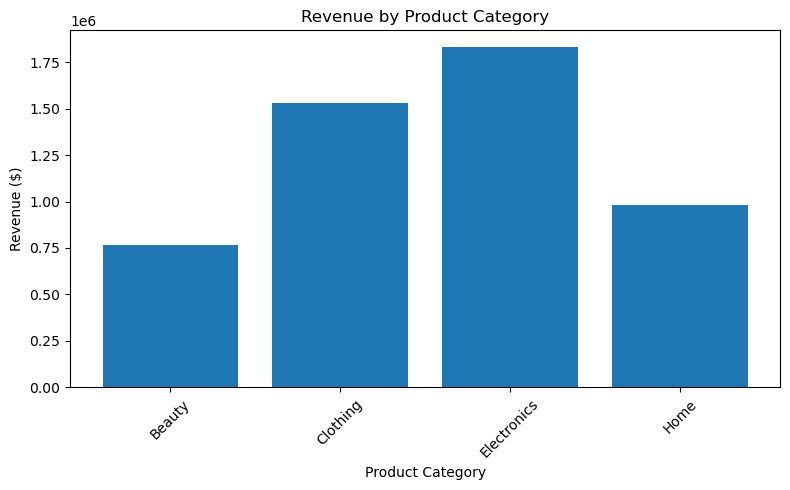

In [29]:
# Plot a agraph for revenue by product category

revenue_by_category = df.groupby('product_category')['revenue'].sum()

plt.figure(figsize=(8, 5))
plt.bar(revenue_by_category.index, revenue_by_category.values)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
The analysis shows that Electronics generated he highest revenue and the least revenue was gotten from beauty.

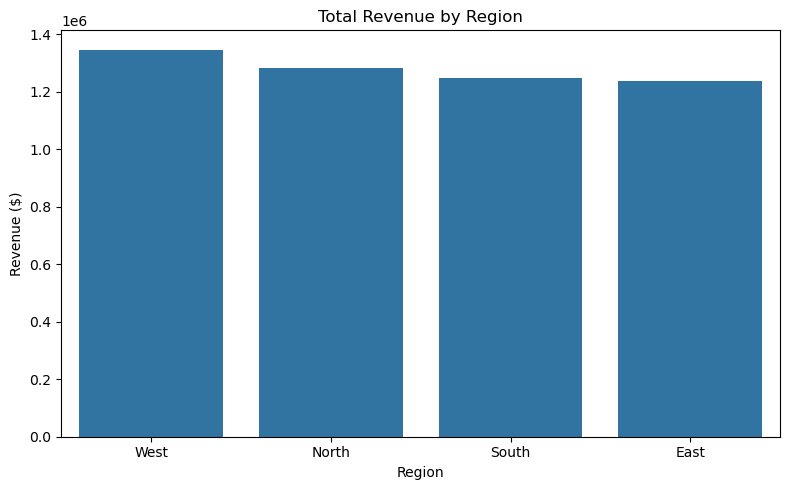

In [36]:
# Identify Revenue by Region

region_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=region_revenue.index, y=region_revenue.values)
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

In [ ]:
The graph shows that highest revenue is from the West while the least revenue is from the East.

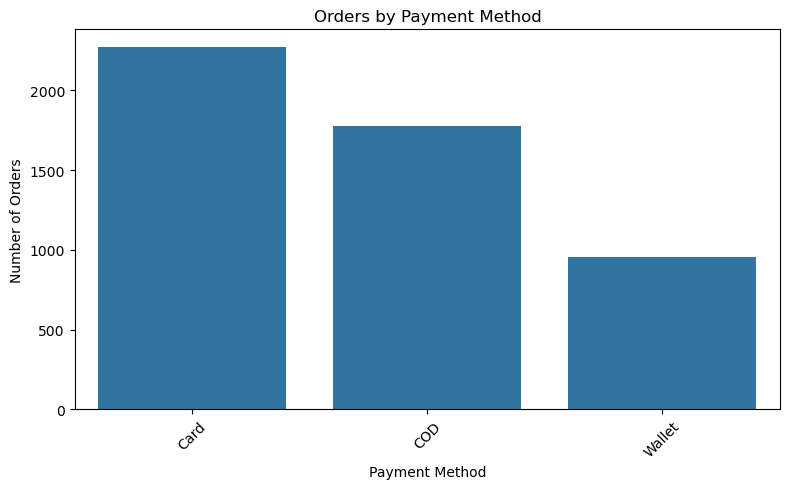

In [37]:
# Identify Payment Methods

payment_counts = df['payment_method'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=payment_counts.index, y=payment_counts.values)
plt.title('Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

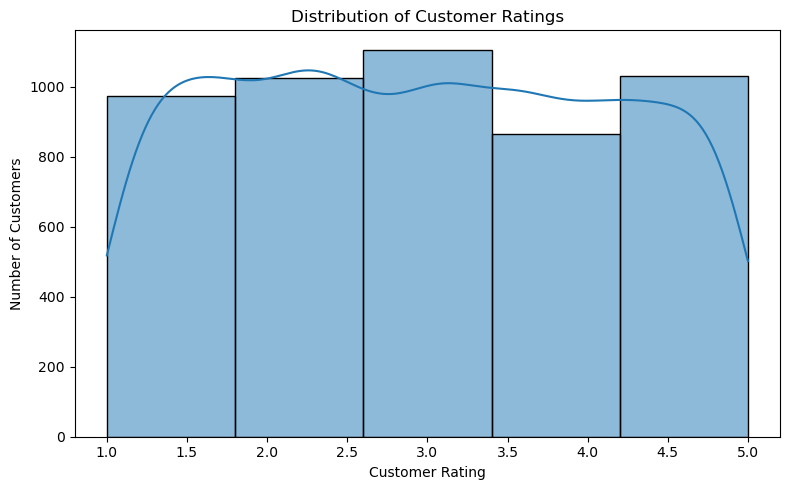

In [38]:
# Plot a graph for distribution of customer rating

plt.figure(figsize=(8,5))
sns.histplot(df['customer_rating'].dropna(), bins=5, kde=True)
plt.title('Distribution of Customer Ratings')
plt.xlabel('Customer Rating')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [ ]:
This analysis shows that the top 2 number of customers rating are 3.0 and 5.0.

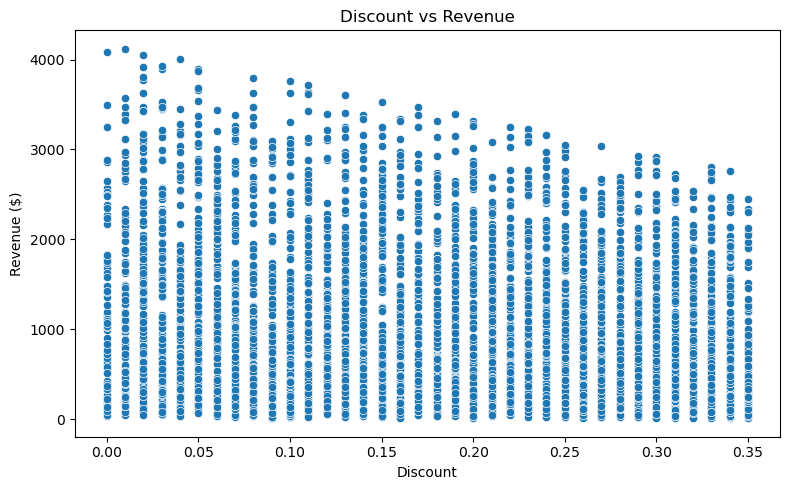

In [39]:
# Identify if discount has effect on revenue

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='discount', y='revenue')
plt.title('Discount vs Revenue')
plt.xlabel('Discount')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

In [ ]:
The chart suggests that higher discounts do not necessarily lead to higher revenue. In fact, the highest
revenue 
values are concentrated at lower discount levels, indicating that increasing discounts may not 
proportionally 
increase revenue.

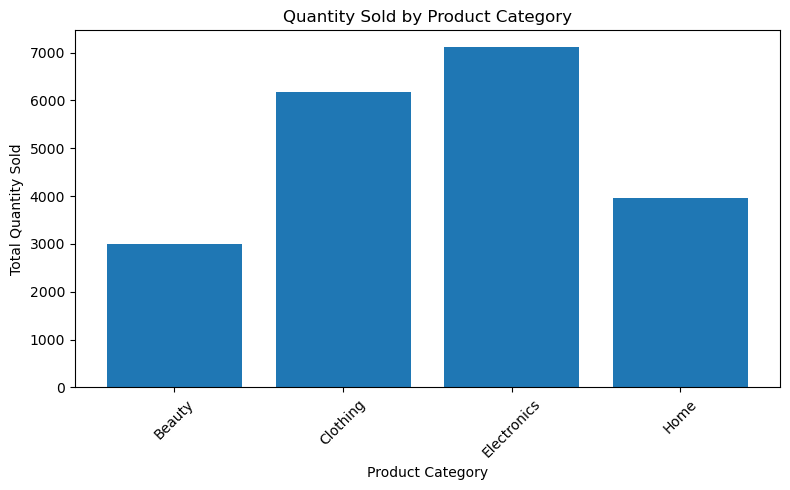

In [5]:
# Identify quantity sold by product category

quantity_by_category = df.groupby('product_category')['quantity'].sum()

plt.figure(figsize=(8, 5))
plt.bar(quantity_by_category.index, quantity_by_category.values)

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
Most sold product category is Electronice and least is Beauty.

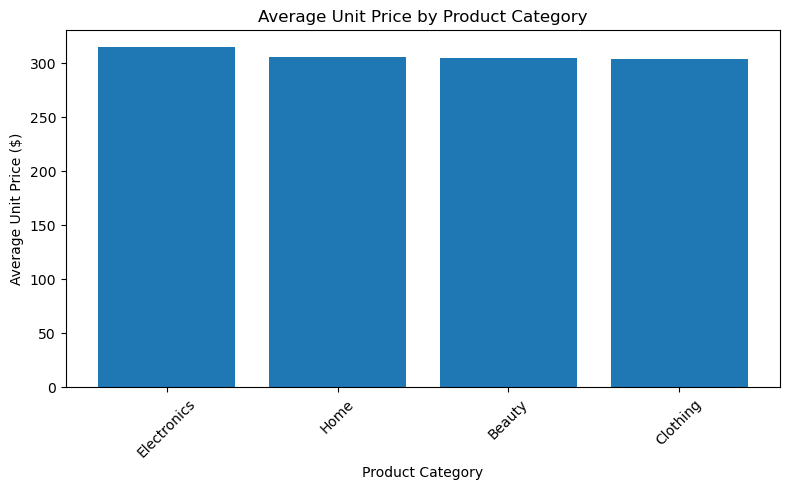

In [10]:
avg_price = df.groupby('product_category')['unit_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(avg_price.index, avg_price.values)

plt.title('Average Unit Price by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Unit Price ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

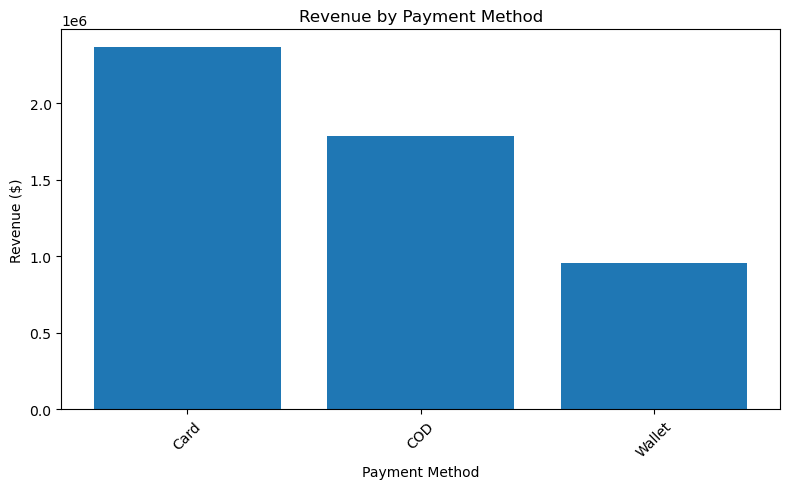

In [12]:
# Plot a graph to identify which payment method geneated the highest and least revenue.

payment_revenue = df.groupby('payment_method')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(payment_revenue.index, payment_revenue.values)

plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

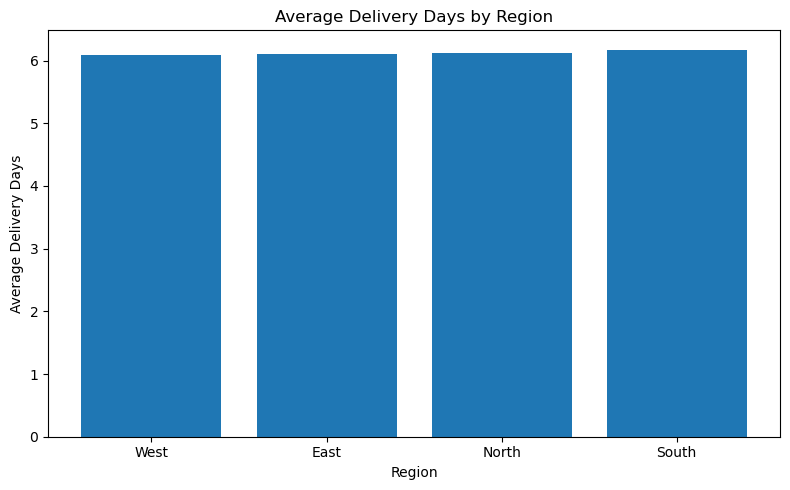

In [11]:
# Plot a graph to show average delivery days by region

delivery_by_region = df.groupby('region')['delivery_days'].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(delivery_by_region.index, delivery_by_region.values)

plt.title('Average Delivery Days by Region')
plt.xlabel('Region')
plt.ylabel('Average Delivery Days')

plt.tight_layout()
plt.show()

In [ ]:
Average delivery days across region is evenly distributed.

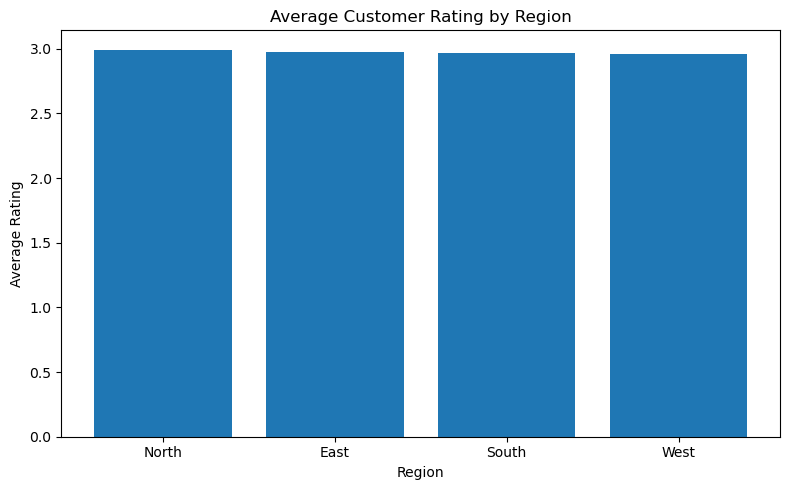

In [13]:
# Plot a graph to determine average customer rating by region

rating_region = df.groupby('region')['customer_rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(rating_region.index, rating_region.values)

plt.title('Average Customer Rating by Region')
plt.xlabel('Region')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

In [ ]:
Customers from the North region rate more. Recall that highest revenue is from the West, yet it's the lowest 
in average rating. This shows that there is there is no linear relation between revenue by region and 
average rating.

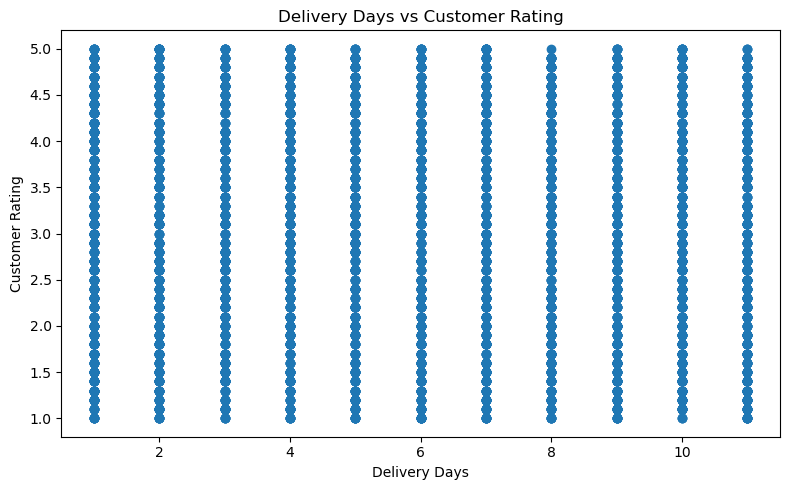

In [7]:
# Plot a graph to check if deliver days have effect on customer rating

plt.figure(figsize=(8, 5))
plt.scatter(df['delivery_days'], df['customer_rating'])

plt.title('Delivery Days vs Customer Rating')
plt.xlabel('Delivery Days')
plt.ylabel('Customer Rating')

plt.tight_layout()
plt.show()

In [ ]:
Customer ratings appear to be relatively independent of delivery time in this dataset. There is no clear 
visual relationship between the number of delivery days and customer satisfaction.

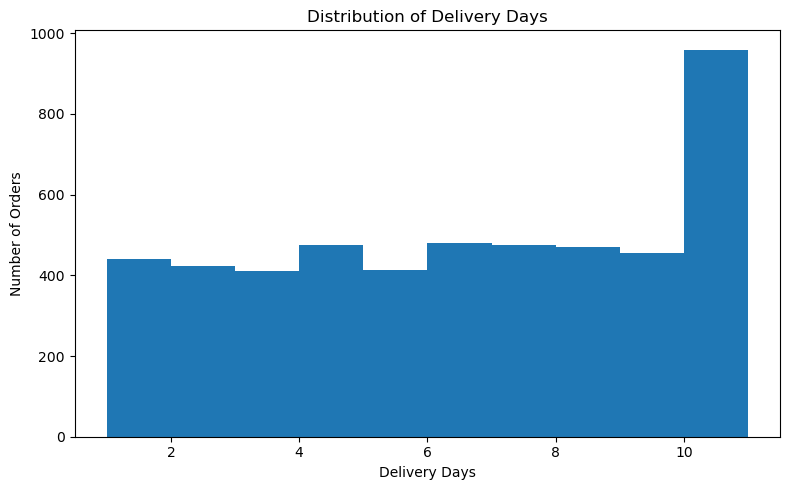

In [8]:
# Plot a graph showing distribution of delivery days

plt.figure(figsize=(8, 5))
plt.hist(df['delivery_days'], bins=10)

plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [ ]:
The graph shows that higher number of orders has high delivery days. It takes longer to deliver larger 
number of orders.

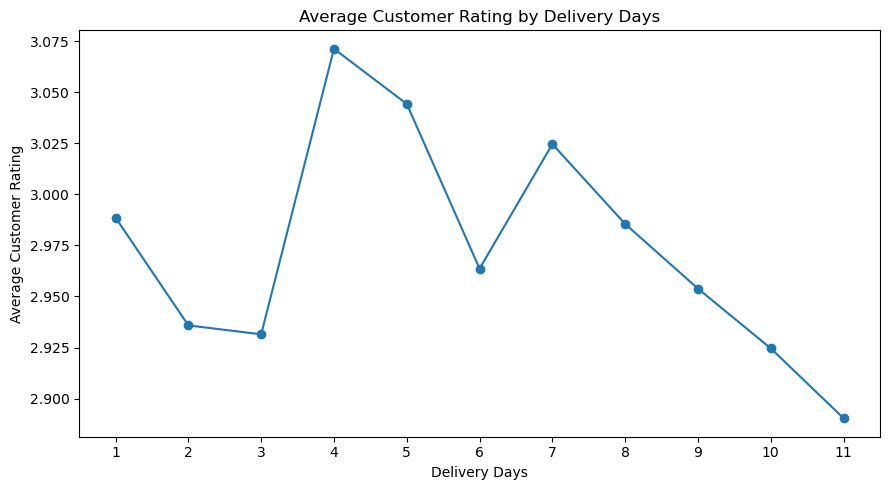

In [9]:
rating_by_delivery = df.groupby('delivery_days')['customer_rating'].mean()

plt.figure(figsize=(9, 5))
plt.plot(rating_by_delivery.index, rating_by_delivery.values, marker='o')

plt.title('Average Customer Rating by Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Average Customer Rating')
plt.xticks(rating_by_delivery.index)

plt.tight_layout()
plt.show()

In [ ]:
Customer ratings generally tend to decline as delivery time becomes longer, particularly from 7 to 11 days. 
The lowest average rating occurs at 11 days, suggesting that prolonged delivery times may negatively
affect customer satisfaction.

In [11]:
df['unit_price'] = df['unit_price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

df['revenue'] = df['revenue'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

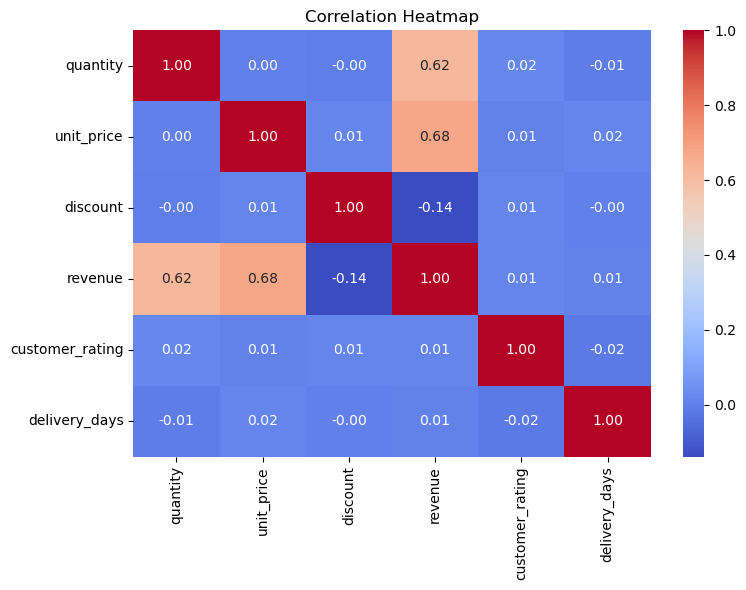

In [12]:
# Plot the correlation heatmap

plt.figure(figsize=(8, 6))

corr = df[['quantity', 'unit_price', 'discount', 'revenue', 
           'customer_rating', 'delivery_days']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
Revenue is most strongly associated with unit price (0.68) and quantity purchased (0.62), while discount, 
customer rating, and delivery days show very weak relationships with revenue. This suggests that sales value
and order quantity are more important drivers of revenue in this dataset than discounts or delivery 
performance.

In [ ]:
# DATA STORY

The E-Commerce-Analysis reveals important patterns in sales performance, customer behavior, and operational
performance. Revenue varies across product categories, with some categories contributing significantly more
to overall sales than others. Quantity sold provides additional insight into customer demand, while
payment-method analysis highlights customer preferences.

The analysis also shows that revenue has a stronger relationship with unit price and quantity than with 
discounts. Customer ratings and delivery days show little overall correlation, although longer delivery 
times appear to coincide with lower average ratings at the highest delivery durations.

These findings provide opportunities for the business to focus on high-performing product categories, 
understand customer preferences, optimize pricing and promotional strategies, and monitor delivery 
performance.

In [ ]:
# BUSINESS RECOMMENDATION

1. Focus on high-performing product categories by ensuring adequate inventory and promoting products with
strong revenue and demand.

2. Review underperforming categories to identify opportunities for improved pricing, marketing, or product
selection.

3. Optimize discount strategies rather than relying heavily on discounts, since discounts show a weak negative
relationship with revenue.

4. Monitor delivery performance, particularly orders taking longer to arrive, as extended delivery times may
affect customer satisfaction.

5. Maintain popular payment methods while ensuring customers have multiple convenient payment options.

6. Use customer ratings to identify areas where customer experience can be improved.

7. Continue monitoring revenue trends over time to identify periods of growth and decline and support better
sales planning.

In [ ]:
## Conclusion

This project transformed raw e-commerce sales data into meaningful visualizations and business insights 
using Python, Pandas, Matplotlib, and Seaborn. The analysis examined revenue trends, product category
performance, customer behavior, payment methods, discounts, customer ratings, and delivery performance.

The findings demonstrate how data visualization can reveal important patterns and support data-driven 
decision-making. The insights generated can help the business improve sales strategies, optimize product 
performance, enhance customer experience, and identify opportunities for future growth.